In [1]:
# ===== ME0SegReco Setup =====
import sys
import site
user_site = site.USER_SITE
me0_src = '/eos/home-i01/k/kkeshav/SWAN_projects/cms_me0_v1/ME0SegReco/src'
for path in [user_site, me0_src]:
    if path not in sys.path:
        sys.path.insert(0, path)
        
from me0.data.datasets.GNNDataset import GNNDataset
from me0.modules.gnn.model import HitGNN
print("✓ ME0SegReco loaded")

✓ ME0SegReco loaded


In [2]:
from time import perf_counter
from torch_geometric.loader import DataLoader
from torch.utils.data import Subset
import torch
from tqdm import tqdm

In [3]:
device = 'cuda'

In [4]:
###
### Dataset construction time
###
start_graph = perf_counter()
dataset = GNNDataset("preprocessed_graph", path='../data/step4_0.h5', d_strip_max=10, d_ieta_max=2, d_bx_max=1)
end_graph = perf_counter()
graph_construction_time = end_graph - start_graph
print(f"Graph_Construction_Time: {graph_construction_time:.3f} seconds")
print(f"Total Graphs Built: {len(dataset)}")

Graph_Construction_Time: 0.221 seconds
Total Graphs Built: 35430


In [5]:
model = HitGNN(input_node_dim=5, edge_dim=5, hidden_dim=10, num_layers=6)

In [6]:
full_loader = DataLoader(dataset,  shuffle=True, drop_last=True, batch_size=128)


In [7]:
###
### GNN Predicition timining
###
model = model.to(device)
start_pred = perf_counter()
with torch.inference_mode():
    for idx_batch in tqdm(full_loader, desc="GNN Batches"):
      idx_batch = idx_batch.to(device)
      model(idx_batch)
end_pred = perf_counter()

GNN Batches: 100%|██████████| 276/276 [00:05<00:00, 51.18it/s]


In [8]:
prediction_time = end_pred - start_pred
total_inference_time = graph_construction_time + prediction_time

In [9]:
print(f" Model prediction time: {prediction_time:.3f} seconds")
print(f"Total inference time: {total_inference_time:.3f} seconds")

 Model prediction time: 5.401 seconds
Total inference time: 5.622 seconds


In [10]:
import matplotlib.pyplot as plt

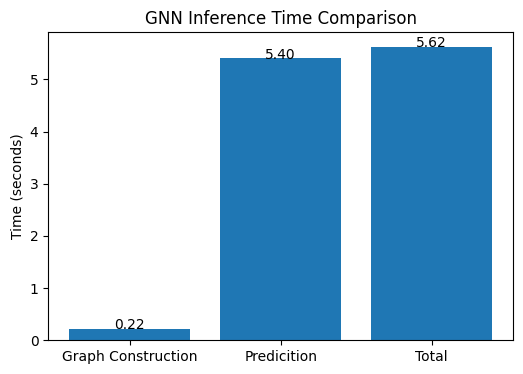

In [11]:
labels = ['Graph Construction','Predicition','Total']
times = [graph_construction_time, prediction_time, total_inference_time]
plt.figure(figsize=(6,4))
plt.bar(labels,times)
# Add values on top (simple)
for i in range(len(times)):
    plt.text(i, times[i], f'{times[i]:.2f}', ha='center')
plt.ylabel('Time (seconds)')
plt.title('GNN Inference Time Comparison')
plt.show()

In [12]:
from me0.modules.cnn.model import ME0SegCNN3d
from me0.data.datasets.image import ME0DigiImageDataset

In [13]:
model = ME0SegCNN3d(
    in_channels = 3, # (hitmap, cls, bx)
    out_channels = 1,
    hidden_channels_list = [2, 4, 2],
    kernel_size = (3, 3, 7),
    activation = "GELU",
).to_tensor_dict_module()

In [14]:
###
### Dataset construction time
###
start_image = perf_counter()
dataset = ME0DigiImageDataset(
    file='../data/step4_0.h5',
    features={
        'cls': {'min': 1, 'max': 384},
        'bx': {'min': -3, 'max': 3},
    },
    get_central_bx=True,
)

end_image = perf_counter()
image_construction_time =  end_image - start_image
print(f"Image_Construction_Time: {image_construction_time:.3f} seconds")

processing 35430 events: 100%|██████████| 1/1 [00:25<00:00, 25.39s/it]

Image_Construction_Time: 25.409 seconds


In [15]:
from torch.utils.data import DataLoader

In [16]:
full_dataset = DataLoader(dataset, collate_fn=dataset.collate,  shuffle=True, drop_last=True, batch_size=128)

In [17]:
len(full_dataset)

276

In [18]:
model = model.to(device)

In [19]:
###
### CNN timing
###
start_pred_cnn = perf_counter()
with torch.inference_mode():
    loss = 0
    for batch in tqdm(full_dataset):
        batch = batch.to(device)
        out = model(batch)
end_pred_cnn = perf_counter()

100%|██████████| 276/276 [01:45<00:00,  2.62it/s]


In [38]:
prediction_time_cnn = end_pred - start_pred
total_inference_time_cnn = image_construction_time + prediction_time_cnn
print(f" Model prediction time: {prediction_time:.3f} seconds")
print(f"Total inference time: {total_inference_time:.3f} seconds")

 Model prediction time: 5.401 seconds
Total inference time: 5.622 seconds


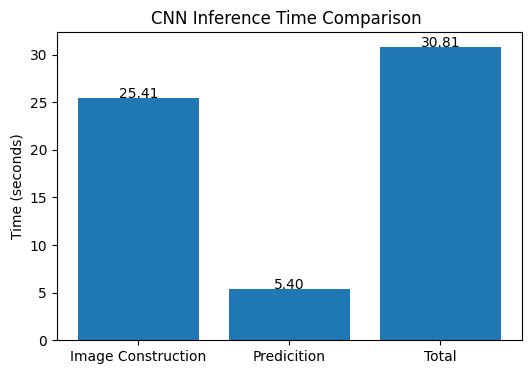

In [21]:
labels = ['Image Construction','Predicition','Total']
times = [image_construction_time, prediction_time_cnn, total_inference_time_cnn]
plt.figure(figsize=(6,4))
plt.bar(labels,times)
for i in range(len(times)):
    plt.text(i, times[i], f'{times[i]:.2f}', ha='center')
plt.ylabel('Time (seconds)')
plt.title('CNN Inference Time Comparison ')
plt.show()

In [42]:
!pip install --user einops einops
import einops
from me0.data.datasets.index import ME0IndexDataset
from me0.modules.transformer.model import ME0Transformer

  Using cached einops-0.8.2-py3-none-any.whl.metadata (13 kB)
Using cached einops-0.8.2-py3-none-any.whl (65 kB)


In [43]:

# ===== Dataset Construction =====
start = perf_counter()
dataset = ME0IndexDataset(
    file='../data/step4_0.h5',
    features={
        'cls': {'min': 1, 'max': 384},
        'bx': {'min': -3, 'max': 3},
    },
)
end = perf_counter()

print(f"Dataset construction time: {end-start:.3f} seconds")


processing 35430 events:   0%|          | 1/35430 [00:03<38:47:55,  3.94s/it]   


Dataset construction time: 4.233 seconds


In [44]:
# ===== Dataset Construction =====
start_data_trans = perf_counter()
dataset = ME0IndexDataset(
    file='../data/step4_0.h5',
    features={
        'cls': {'min': 1, 'max': 384},
        'bx': {'min': -3, 'max': 3},
    },
)
end_data_trans = perf_counter()
data_time_transformer =  end_data_trans - start_data_trans
print(f"data_time_transformer: {data_time_transformer} seconds")


processing 35430 events:   0%|          | 1/35430 [00:05<53:58:21,  5.48s/it]   


data_time_transformer: 5.795871257025283 seconds


In [45]:
model = ME0Transformer(
    dim_input=5, num_layers=4, dim_model=128,
    num_heads=8, dim_feedforward=512,
    activation="gelu", norm_first=True, bias=False,
).to_tensor_dict_module()

In [46]:
full_loader = DataLoader(dataset, collate_fn=dataset.collate,
                         shuffle=False, drop_last=True, batch_size=128)


In [47]:
###
### Transformer timing
###
model = model.to(device)
start = perf_counter()
with torch.inference_mode():
    for idx_batch in tqdm(full_loader, desc="Transformer Batches"):
        # Move TensorDict to device (keep it as TensorDict)
        idx_batch = idx_batch.to(device)
        model(idx_batch)
end = perf_counter()

Transformer Batches: 100%|██████████| 276/276 [01:18<00:00,  3.53it/s]


In [41]:
pred_time = end - start

total_time = data_time_transformer + pred_time
print(f" Model prediction time: {pred_time:.3f} seconds")
print(f"Total inference time: {total_time:.3f} seconds")

 Model prediction time: 79.080 seconds
Total inference time: 88.007 seconds


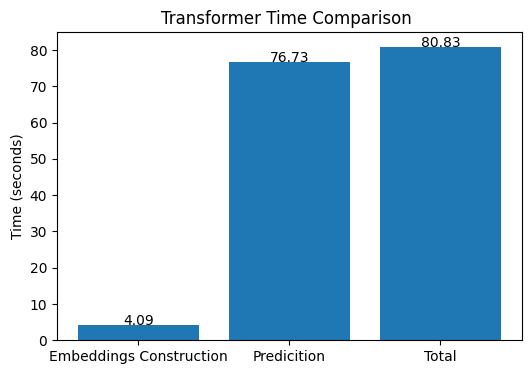

In [39]:
labels = ['Embeddings Construction','Predicition','Total']
times = [data_time_transformer, pred_time, total_time]
plt.figure(figsize=(6,4))
plt.bar(labels,times)
for i in range(len(times)):
    plt.text(i, times[i], f'{times[i]:.2f}', ha='center')
plt.ylabel('Time (seconds)')
plt.title('Transformer Time Comparison ')
plt.show()